In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from model import cnn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [3]:
model = cnn()
model.load_state_dict(torch.load('saved_model/best.pth'))

<All keys matched successfully>

In [5]:
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [6]:
test_data = datasets.ImageFolder(root='./dataset/test',transform=test_transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9607843].


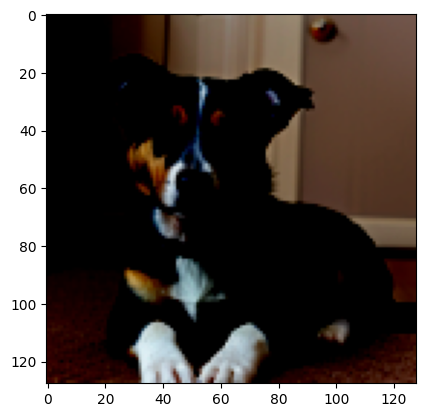

In [11]:
img = test_data[100][0]
img = img.permute(1,2,0)
plt.imshow(img)

In [12]:
img = test_data[100][0].reshape(1,3,128,128)
act = ['Cat','Dog']

model.eval()
with torch.no_grad():
    pred = model(img)
    prob = torch.sigmoid(pred)

    val = (prob > 0.5).long()
    print(act[val])

Dog
